# Synthetic Experiment With Permutation Calibration

Companion notebook for calibrated metric sweeps. The original `synthetic_experiment.ipynb` remains the uncalibrated workflow.

In [ ]:
import json
import os
import datetime

import numpy as np
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA, KernelPCA
from sklearn.manifold import TSNE

from synthetic_datasets.base_dataset import BaseDataset, TransformConfig
from synthetic_datasets import init_dataset, get_transform_config
from manifold_repsim.experiments.legacy import get_data_param_sweep_values, run_param_sweep, plot_param_sweep
from manifold_repsim.sweeps import (
    aggregate_signal_auc,
    aggregate_signal_variance_weighted_auc,
    compute_aggregate_permutation_calibration,
)


sim_params = {
    "sim_name": "high_noise",  # "low_noise", "high_noise", "unbalanced", "uniform_grid", "nonuniform_grid"
    "dataset_type": "permuted_gaussian_clusters",  # "gaussian_cluster", "permuted_gaussian_clusters", "s_curve", "rings", "s_clusters", "ellipsoid"
    "date time": datetime.datetime.now().strftime("%Y-%m-%d_%H-%M-%S"),
    "n_points": 500,
    "sigma": 1.0,
    "noise_scale": 0.01,
    "seed": 31,
    "dim": 2,
    "n_clusters": 9,  # shared by base and current permuted Gaussian mixtures
    "balanced": True,  # False gives every cluster a distinct positive number of points
    "center_sampling": "hypersphere",  # "hypersphere", "uniform_grid", or "nonuniform_grid"
    "permuted_data_param": "noise_scale",  # "n_permute" or "cluster_mixing_probability", "noise_scale""
    "metric_param_sweep_len": 40,
    "metric_sweep_ranges": {
        "cka_rbf": {"min": 0.01, "max": 5.0},
        "rbf_uka": {"min": 0.01, "max": 5.0},
        "rbf_rwka_diffusion_time": {"min": 0.01, "max": 1000.0},
        "rbf_rwka_symmetric": {"min": 0.01, "max": 5.0},
        "rbf_crwka": {"min": 0.01, "max": 5.0},
        "rbf_degree_crwka": {"min": 0.01, "max": 5.0},
    },
    "data_param_sweep_len": 6,
    "radius_type": "median",
    "visualization_method": "pca",
    "clusters_type": "closest",
    "auc_integration_method": "average",
    "logscale": True,
    "cutoff_threshold": 0.15,
    "permutation_test": True,
    "n_permutations": 5,
    "calibration_alpha": 0.05,
    "permutation_seed": 42,
    "aggregate_calibration": True,
    "aggregate_calibration_kinds": ["auc", "variance_weighted_auc"],
}

base_transform_params = {
    "n_permute": 0,
    "cluster_mixing_probability": 0.0,
    "center_sampling": sim_params["center_sampling"],
    "n_clusters": 5,
    "n_rings": 7,
    "sigma": sim_params["sigma"],
    "seed": sim_params["seed"],
    "dim": sim_params["dim"],
    "radius_type": sim_params["radius_type"],
    "clustering_type": sim_params["clusters_type"],
    "t": 1.0,
    "noise_scale": 0.05,
    "noise_distribution": "gaussian",  # "gaussian", "uniform", or "student_t"
    "student_t_df": 3.0,
    "cluster_noise_scales": None,  # or one standard-deviation scale per cluster
    "axis_scale": 0.2,
}

current_transform_params = {
    "n_permute": 3,
    "cluster_mixing_probability": 0.15,
    "center_sampling": "hypersphere",  # independently choose the transformed cluster-center layout
    "n_clusters": 7,
    "n_rings": 5,
    "sigma": sim_params["sigma"],
    "seed": sim_params["seed"] + (sim_params["dataset_type"] == "permuted_gaussian_clusters"),
    "dim": sim_params["dim"],
    "radius_type": sim_params["radius_type"],
    "clustering_type": sim_params["clusters_type"],
    "t": 0.6,
    "noise_scale": 0.15,
    "noise_distribution": "gaussian",  # "gaussian", "uniform", or "student_t"
    "student_t_df": 3.0,
    "cluster_noise_scales": None,  # or one standard-deviation scale per cluster
    "axis_scale": 0.2,
}

balanced_str = "_balanced" if sim_params["balanced"] else ""
if sim_params["dataset_type"] == "permuted_gaussian_clusters":
    base_center_sampling = base_transform_params.get("center_sampling")
    if base_center_sampling is None:
        base_center_sampling = sim_params["center_sampling"]
    transform_center_sampling = current_transform_params.get("center_sampling")
    if transform_center_sampling is None:
        transform_center_sampling = sim_params["center_sampling"]
    center_sampling_str = f"_base-{base_center_sampling}_transform-{transform_center_sampling}"
    base_noise_distribution = base_transform_params.get("noise_distribution", "gaussian")
    transform_noise_distribution = current_transform_params.get("noise_distribution", "gaussian")
    base_noise_profile = "per-cluster" if base_transform_params.get("cluster_noise_scales") is not None else "scalar"
    transform_noise_profile = "per-cluster" if current_transform_params.get("cluster_noise_scales") is not None else "scalar"
    noise_sampling_str = f"_base-noise-{base_noise_distribution}-{base_noise_profile}_transform-noise-{transform_noise_distribution}-{transform_noise_profile}"
    mixing_str = f"_sweep-{sim_params['permuted_data_param']}_base-mix-{base_transform_params['cluster_mixing_probability']:g}_transform-mix-{current_transform_params['cluster_mixing_probability']:g}"
else:
    center_sampling_str = ""
    noise_sampling_str = ""
    mixing_str = ""
figures_path = os.path.join("figures", "synthetic_experiment_calibrated", sim_params['sim_name'],
                            f"{sim_params['dataset_type']}{balanced_str}{center_sampling_str}{noise_sampling_str}{mixing_str}_{sim_params['clusters_type']}")
os.makedirs(figures_path, exist_ok=True)

sim_params["base_transform_params"] = base_transform_params
sim_params["current_transform_params"] = current_transform_params

dataset: BaseDataset = init_dataset(sim_params)
base_transform_config: TransformConfig = get_transform_config(transform_params=base_transform_params, dataset=dataset)
dataset.transform_base(base_transform_config)

with open(f"{figures_path}/sim_params.json", "w") as f:
    json.dump(sim_params, f, indent=4)


In [26]:
def plot_data(dataset: BaseDataset, title="Data", ax=None, visualization_method="pca", base_data=False):
    data = dataset.get_base_numpy() if base_data else dataset.get_current_numpy()
    plot_labels = dataset.plot_labels
    dim = data.shape[1]
    if dim == 2:
        plot_data = data
    elif visualization_method == "pca":
        plot_data = PCA(n_components=2).fit_transform(data)
    elif visualization_method == "kpca":
        plot_data = KernelPCA(n_components=2, kernel="rbf", gamma=0.1).fit_transform(data)
    elif visualization_method == "tsne":
        plot_data = TSNE(n_components=2, perplexity=30, n_iter=300).fit_transform(data)
    else:
        raise ValueError(f"Unsupported visualization method: {visualization_method}")

    if ax is None:
        _, ax = plt.subplots(figsize=(6, 6))
    if np.issubdtype(np.asarray(plot_labels).dtype, np.integer):
        n_categories = int(getattr(dataset.config, "n_clusters", np.max(plot_labels) + 1))
        categorical_cmap = "tab10" if n_categories <= 10 else "turbo"
        ax.scatter(plot_data[:, 0], plot_data[:, 1], c=plot_labels, cmap=plt.get_cmap(categorical_cmap, n_categories), vmin=-0.5, vmax=n_categories - 0.5, alpha=0.5)
    else:
        ax.scatter(plot_data[:, 0], plot_data[:, 1], c=plot_labels, cmap="twilight", alpha=0.5)
    ax.set_title(title)
    ax.set_aspect("equal")
    return ax


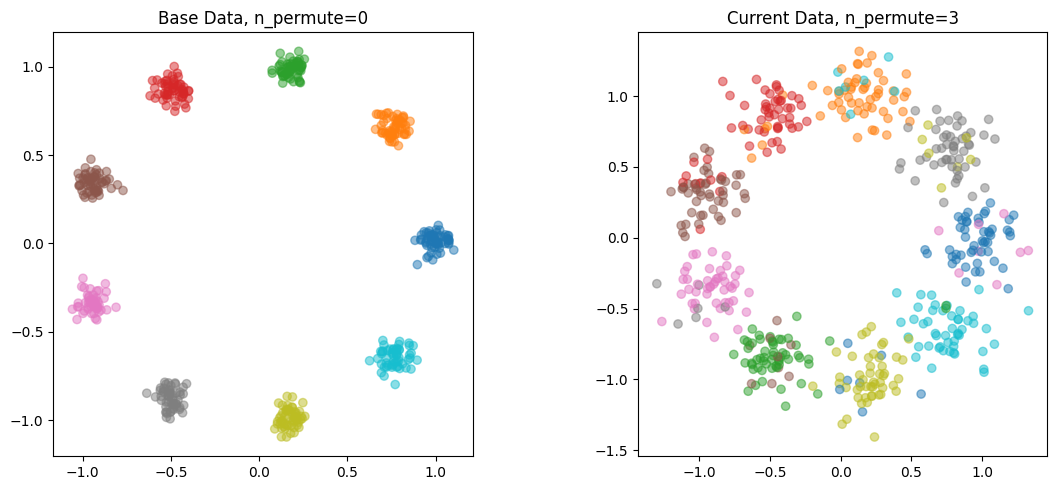

In [27]:
current_config = get_transform_config(transform_params=current_transform_params, dataset=dataset)
dataset.transform_current(current_config)
visualization_param_name = sim_params["permuted_data_param"] if sim_params["dataset_type"] == "permuted_gaussian_clusters" else "t"

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
plot_data(dataset, title=f"Base Data, {visualization_param_name}={base_transform_params[visualization_param_name]}", ax=axes[0], visualization_method=sim_params["visualization_method"], base_data=True)
plot_data(dataset, title=f"Current Data, {visualization_param_name}={current_transform_params[visualization_param_name]}", ax=axes[1], visualization_method=sim_params["visualization_method"])
plt.tight_layout()
plt.savefig(os.path.join(figures_path, "data_visualization.png"), dpi=300)


## Calibrated Metric Parameter Sweep

In [ ]:
metric_name = "rbf_rwka_diffusion_time"
rbf_sigma_values = [0.05, 0.2, 0.5, 1.0, 2.0]
active_rbf_sigma = 0.2
if sim_params["dataset_type"] == "permuted_gaussian_clusters":
    data_param_name = sim_params["permuted_data_param"]
    data_param_values = get_data_param_sweep_values(dataset, data_param_name, sim_params["data_param_sweep_len"])
else:
    data_param_name = "t"
    data_param_values = np.linspace(0, 1, 9)
plot_kind = "line"

current_config = get_transform_config(transform_params=current_transform_params, dataset=dataset)
sigma_sweep_results = {}

for rbf_sigma in rbf_sigma_values:
    sweep_result = run_param_sweep(
        metric_name=metric_name,
        dataset=dataset,
        base_transform_config=base_transform_config,
        transform_config=current_config,
        data_param_name=data_param_name,
        data_param_values=data_param_values,
        metric_sweep_len=sim_params["metric_param_sweep_len"],
        metric_sweep_values=None,
        metric_sweep_range=sim_params["metric_sweep_ranges"].get(metric_name),
        logscale=sim_params["logscale"],
        permutation_test=sim_params["permutation_test"],
        n_permutations=sim_params["n_permutations"],
        calibration_alpha=sim_params["calibration_alpha"],
        permutation_seed=sim_params["permutation_seed"],
        metric_kwargs={"rbf_sigma": rbf_sigma},
    )

    if sim_params["permutation_test"]:
        row_metric_param_name, row_data_param_values, row_metric_sweep_values, row_score_grid, row_inf_scores, row_calibration_result = sweep_result
    else:
        row_metric_param_name, row_data_param_values, row_metric_sweep_values, row_score_grid, row_inf_scores = sweep_result
        row_calibration_result = None

    sigma_sweep_results[rbf_sigma] = {
        "metric_param_name": row_metric_param_name,
        "data_param_values": row_data_param_values,
        "metric_sweep_values": row_metric_sweep_values,
        "score_grid": row_score_grid,
        "inf_scores": row_inf_scores,
        "calibration_result": row_calibration_result,
    }

    sigma_figures_path = os.path.join(figures_path, f"rbf_sigma_{rbf_sigma:g}")
    os.makedirs(sigma_figures_path, exist_ok=True)
    row_per_row_sweep = isinstance(row_metric_sweep_values, (list, tuple)) or (
        isinstance(row_metric_sweep_values, np.ndarray) and np.asarray(row_metric_sweep_values).ndim == 2
    )

    if row_calibration_result is not None:
        fig, ax = plt.subplots(figsize=(11, 6))
        plot_colors = plt.cm.magma(np.linspace(0.08, 0.95, len(row_data_param_values)))
        for row_idx, (data_param_value, color) in enumerate(zip(row_data_param_values, plot_colors)):
            row_metric_params = row_metric_sweep_values[row_idx] if row_per_row_sweep else row_metric_sweep_values
            label = f"{data_param_name}={data_param_value:.2f}" if data_param_name != "dim" else f"dim={int(data_param_value)}"
            ax.plot(row_metric_params, row_score_grid[row_idx], marker="o", linewidth=2, color=color, label=label)
            tau_alpha = row_calibration_result.tau_alpha[row_idx]
            ax.plot(row_metric_params, tau_alpha, linestyle="--", linewidth=1.6, color=color, alpha=0.85)
        if sim_params["logscale"]:
            ax.set_xscale("log")
        ax.set_xlabel(row_metric_param_name)
        ax.set_ylabel(metric_name)
        ax.set_title(f"{metric_name} signal and permutation null across {data_param_name} ($\sigma_{{rbf}}$={rbf_sigma:g})")
        ax.grid(True, alpha=0.3)
        ax.legend(loc="best", fontsize=9, ncol=2)
        plt.tight_layout()
        plt.savefig(
            os.path.join(sigma_figures_path, f"{data_param_name}_{metric_name}_{row_metric_param_name}_sweep_with_permutation_overlay.png"),
            dpi=300,
        )
    else:
        fig, ax = plot_param_sweep(
            metric_name=metric_name,
            plot_kind=plot_kind,
            metric_param_name=row_metric_param_name,
            metric_param_values=row_metric_sweep_values,
            data_param_name=data_param_name,
            data_param_values=row_data_param_values,
            score_grid=row_score_grid,
            inf_scores=row_inf_scores,
            sim_params=sim_params,
            save_path=sigma_figures_path,
            logscale=sim_params["logscale"],
        )
        ax.set_title(f"{metric_name} vs. {row_metric_param_name} for different {data_param_name} values ($\sigma_{{rbf}}$={rbf_sigma:g})")

active_result = sigma_sweep_results[active_rbf_sigma]
metric_param_name = active_result["metric_param_name"]
data_param_values = active_result["data_param_values"]
metric_sweep_values = active_result["metric_sweep_values"]
score_grid = active_result["score_grid"]
inf_scores = active_result["inf_scores"]
calibration_result = active_result["calibration_result"]

per_row_sweep = isinstance(metric_sweep_values, (list, tuple)) or (
    isinstance(metric_sweep_values, np.ndarray) and np.asarray(metric_sweep_values).ndim == 2
)


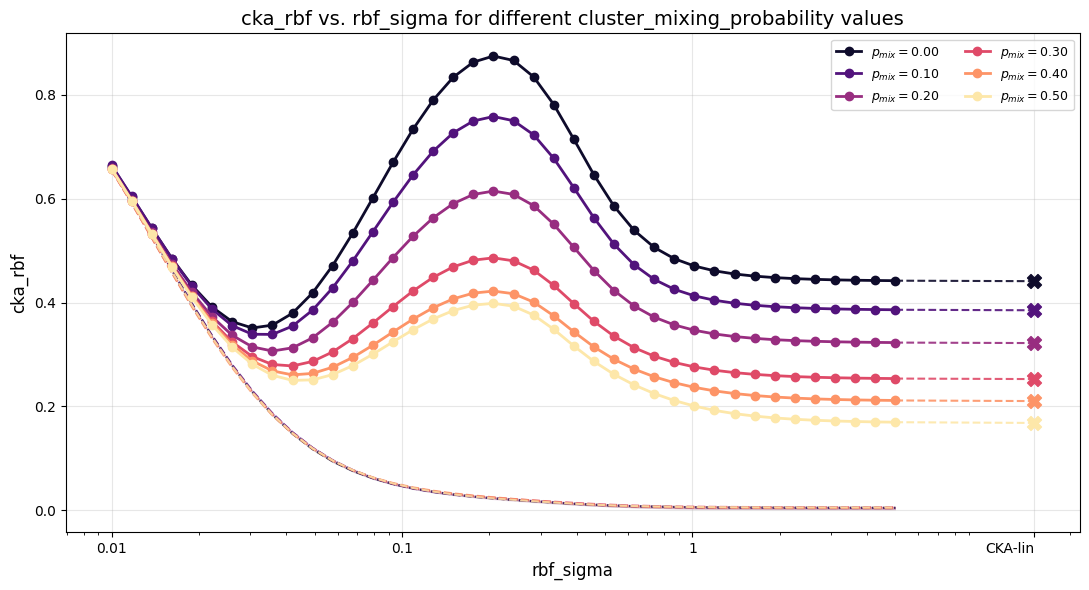

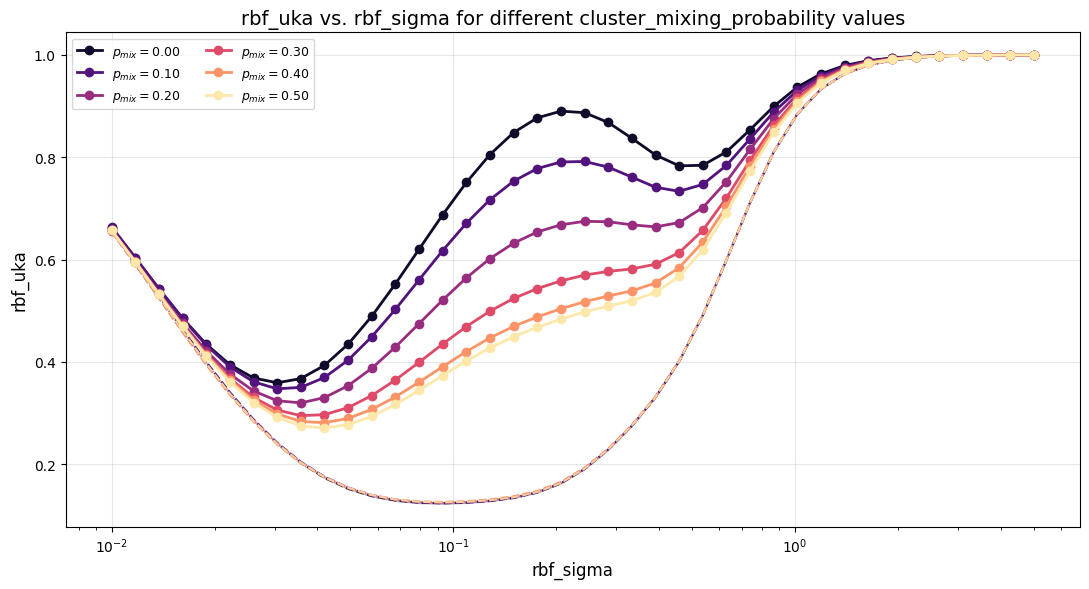

In [ ]:
# signal_metric_names = ["cka_rbf", "rbf_uka", "rbf_rwka_symmetric", "rbf_crwka", "rbf_degree_crwka"]
signal_metric_names = ["cka_rbf", "rbf_uka"]
if sim_params["dataset_type"] == "permuted_gaussian_clusters":
    data_param_name = sim_params["permuted_data_param"]
    data_param_values = get_data_param_sweep_values(dataset, data_param_name, sim_params["data_param_sweep_len"])
else:
    data_param_name = "t"
    data_param_values = np.linspace(0, 1, 9)
plot_kind = "line"

signal_sweep_results = {}
for metric_name in signal_metric_names:
    current_config = get_transform_config(transform_params=current_transform_params, dataset=dataset)
    sweep_result = run_param_sweep(
        metric_name=metric_name,
        dataset=dataset,
        base_transform_config=base_transform_config,
        transform_config=current_config,
        data_param_name=data_param_name,
        data_param_values=data_param_values,
        metric_sweep_len=sim_params["metric_param_sweep_len"],
        metric_sweep_values=None,
        metric_sweep_range=sim_params["metric_sweep_ranges"].get(metric_name),
        logscale=sim_params["logscale"],
        permutation_test=sim_params["permutation_test"],
        n_permutations=sim_params["n_permutations"],
        calibration_alpha=sim_params["calibration_alpha"],
        permutation_seed=sim_params["permutation_seed"],
    )

    if sim_params["permutation_test"]:
        metric_param_name, row_data_values, metric_sweep_values, score_grid, inf_scores, calibration_result = sweep_result
    else:
        metric_param_name, row_data_values, metric_sweep_values, score_grid, inf_scores = sweep_result
        calibration_result = None

    signal_sweep_results[metric_name] = {
        "metric_param_name": metric_param_name,
        "data_param_values": row_data_values,
        "metric_sweep_values": metric_sweep_values,
        "score_grid": score_grid,
        "inf_scores": inf_scores,
        "calibration_result": calibration_result,
    }

    fig, ax = plot_param_sweep(
        metric_name=metric_name,
        plot_kind=plot_kind,
        metric_param_name=metric_param_name,
        metric_param_values=metric_sweep_values,
        data_param_name=data_param_name,
        data_param_values=row_data_values,
        score_grid=score_grid,
        inf_scores=inf_scores,
        sim_params=sim_params,
        save_path=figures_path,
        logscale=sim_params["logscale"],
        calibration_result=calibration_result,
    )


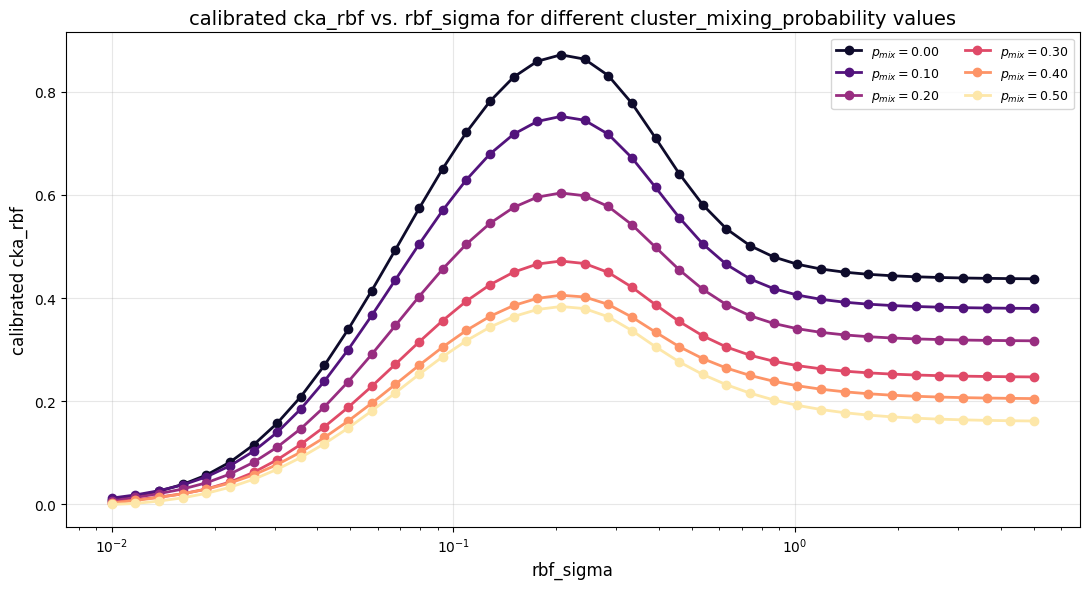

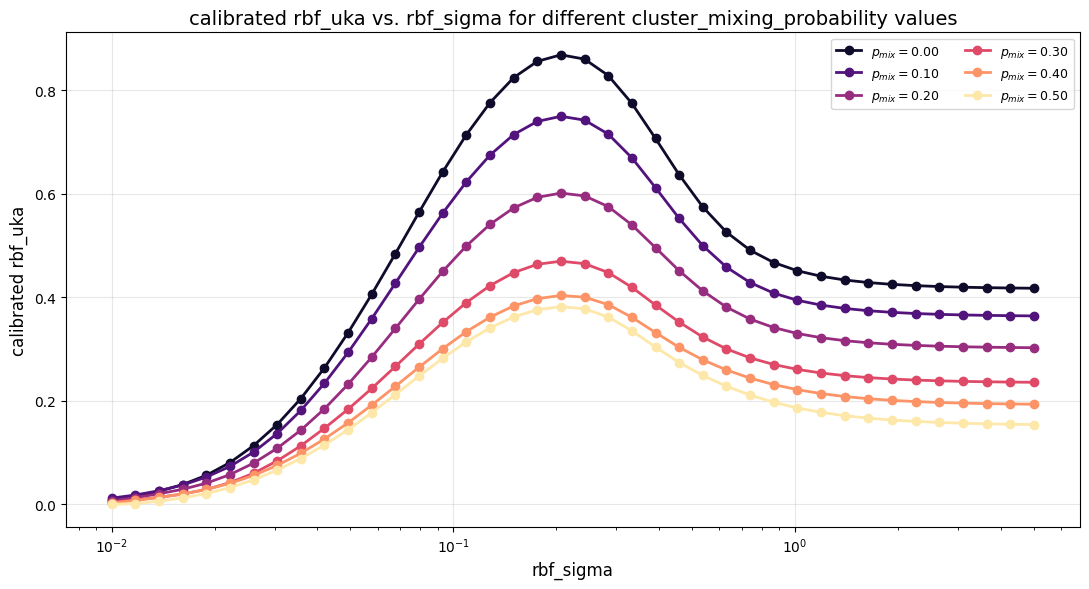

In [ ]:
for metric_name, result in signal_sweep_results.items():
    calibration_result = result["calibration_result"]
    if calibration_result is None:
        continue
    fig, ax = plot_param_sweep(
        metric_name=metric_name,
        plot_kind=plot_kind,
        metric_param_name=result["metric_param_name"],
        metric_param_values=result["metric_sweep_values"],
        data_param_name=data_param_name,
        data_param_values=result["data_param_values"],
        score_grid=result["score_grid"],
        inf_scores=result["inf_scores"],
        sim_params=sim_params,
        save_path=figures_path,
        logscale=sim_params["logscale"],
        calibration_result=calibration_result,
        plot_calibrated=True,
    )


## Metric Signals at Each Data Transform Value

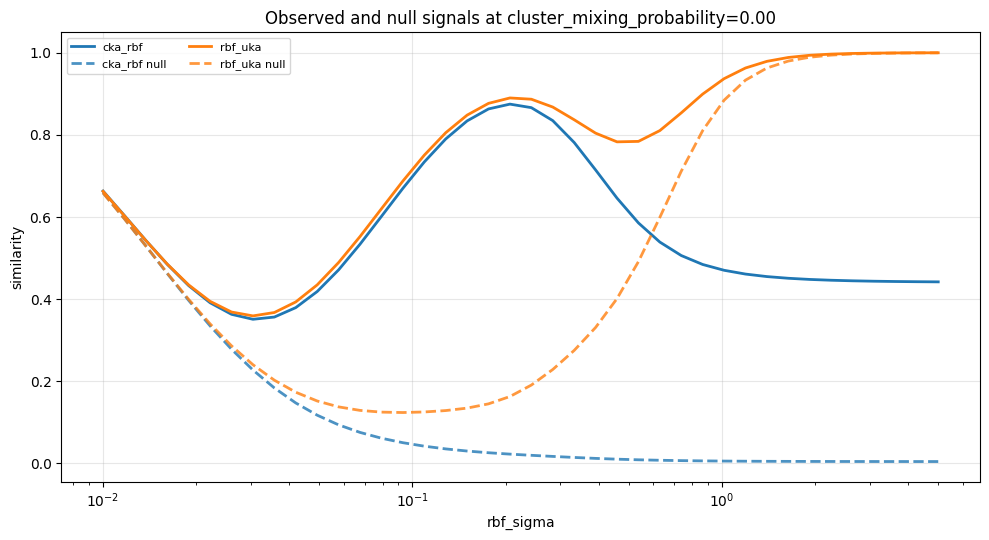

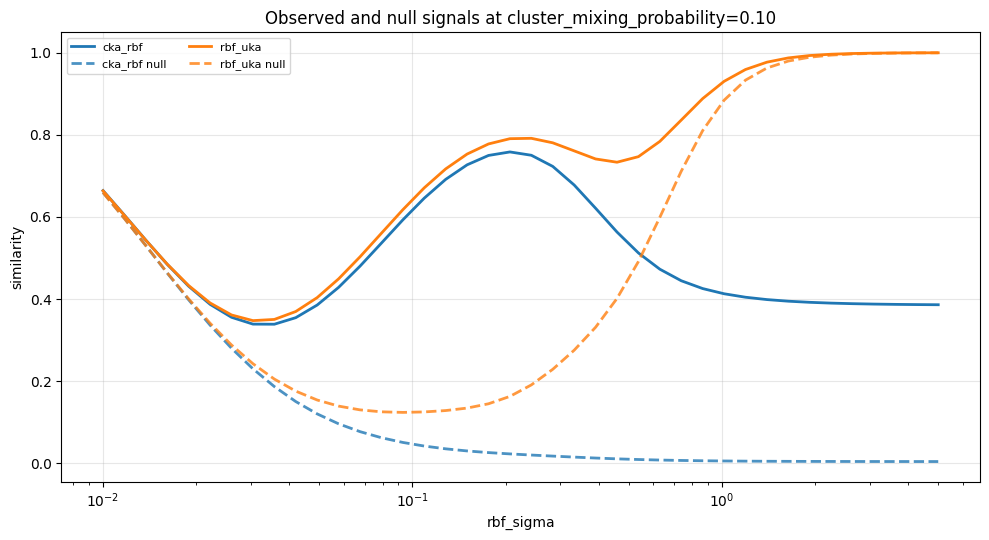

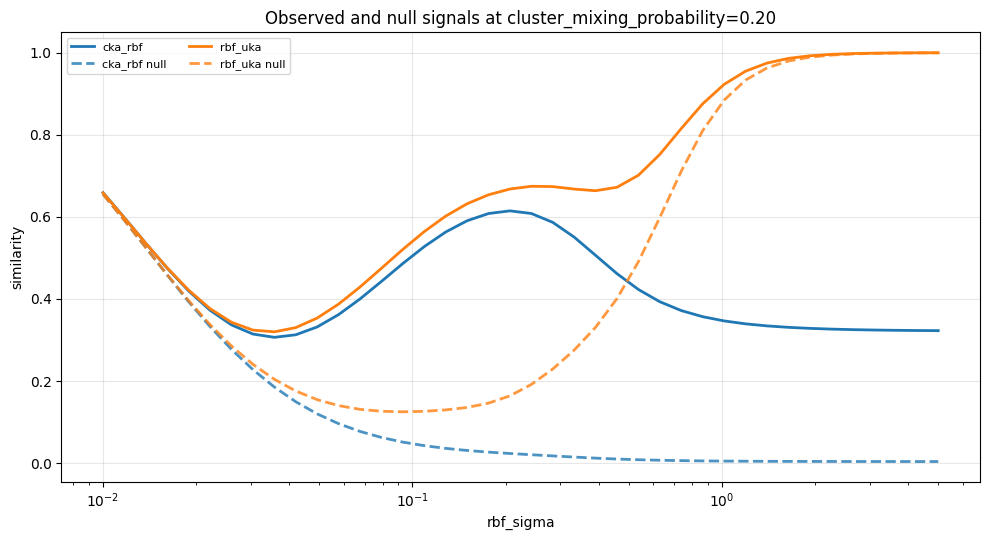

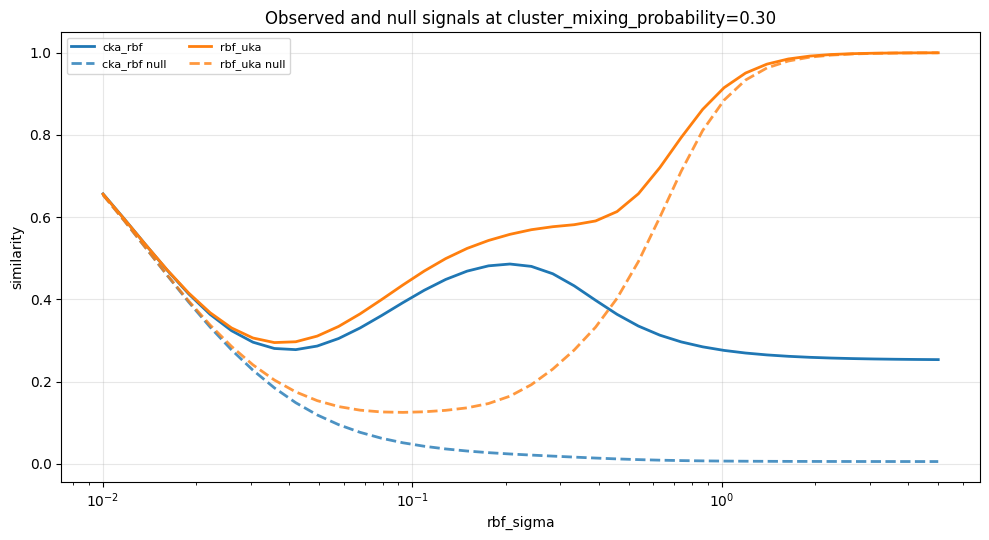

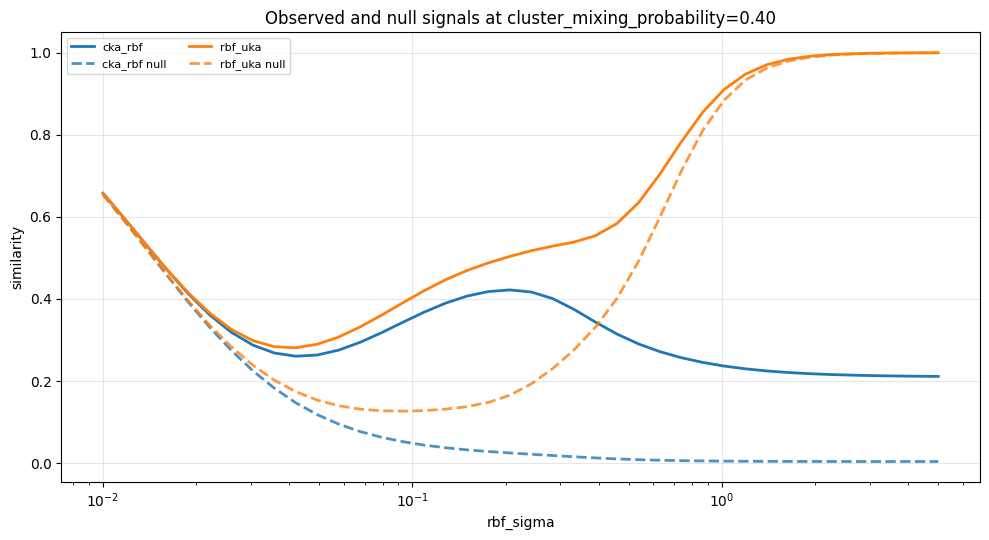

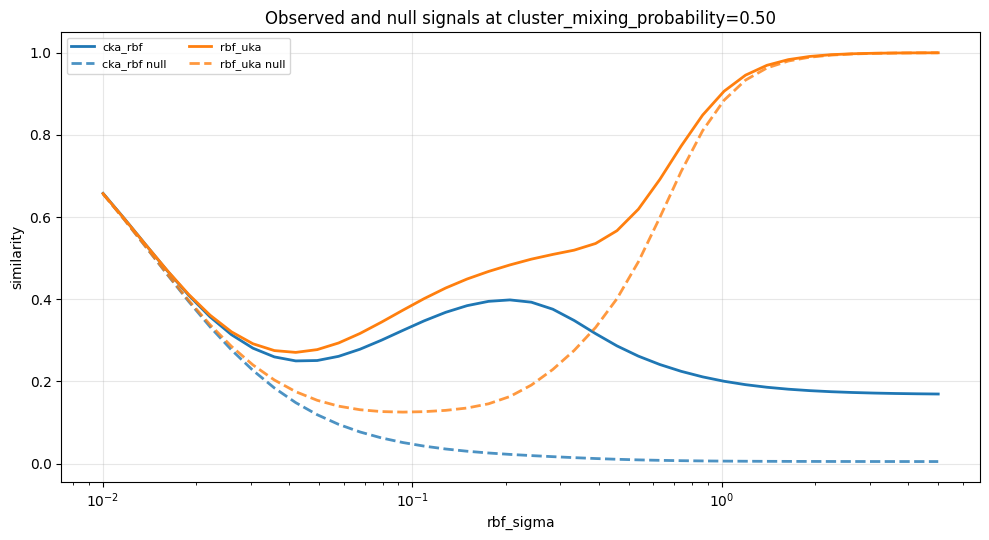

In [ ]:
comparison_data_values = next(iter(signal_sweep_results.values()))["data_param_values"]
metric_param_names = {result["metric_param_name"] for result in signal_sweep_results.values()}
comparison_x_label = next(iter(metric_param_names)) if len(metric_param_names) == 1 else "metric sweep parameter"
permutation_signal_figures_path = os.path.join(figures_path, "permutation_signal_comparison")
os.makedirs(permutation_signal_figures_path, exist_ok=True)

for data_value in comparison_data_values:
    fig, ax = plt.subplots(figsize=(10, 5.5))

    for metric_name, result in signal_sweep_results.items():
        result_data_values = np.asarray(result["data_param_values"])
        matching_rows = np.flatnonzero(np.isclose(result_data_values.astype(float), float(data_value)))
        if matching_rows.size != 1:
            raise ValueError(f"Expected one {data_param_name}={data_value} row for {metric_name}.")
        row_idx = matching_rows[0]
        metric_values = np.asarray(result["metric_sweep_values"])
        row_metric_values = metric_values[row_idx] if metric_values.ndim == 2 else metric_values

        observed_line, = ax.plot(
            row_metric_values,
            result["score_grid"][row_idx],
            linewidth=2,
            label=metric_name,
        )
        calibration_result = result["calibration_result"]
        if calibration_result is not None:
            ax.plot(
                row_metric_values,
                calibration_result.null_mean[row_idx],
                color=observed_line.get_color(),
                linewidth=2,
                linestyle="--",
                alpha=0.8,
                label=f"{metric_name} null",
            )

    ax.set_xlabel(comparison_x_label)
    ax.set_ylabel("similarity")
    ax.set_title(f"Observed and null signals at {data_param_name}={data_value:.2f}")
    if sim_params["logscale"]:
        ax.set_xscale("log")
    ax.grid(True, alpha=0.3)
    ax.legend(loc="best", fontsize=8, ncols=2)

    value_slug = str(data_value).replace(".", "p").replace("-", "m")
    fig.tight_layout()
    fig.savefig(
        os.path.join(permutation_signal_figures_path, f"{data_param_name}_{value_slug}_all_metric_signals.png"),
        dpi=300,
    )
    plt.show()
    plt.close(fig)


## AUC Across the Data Transform Parameter

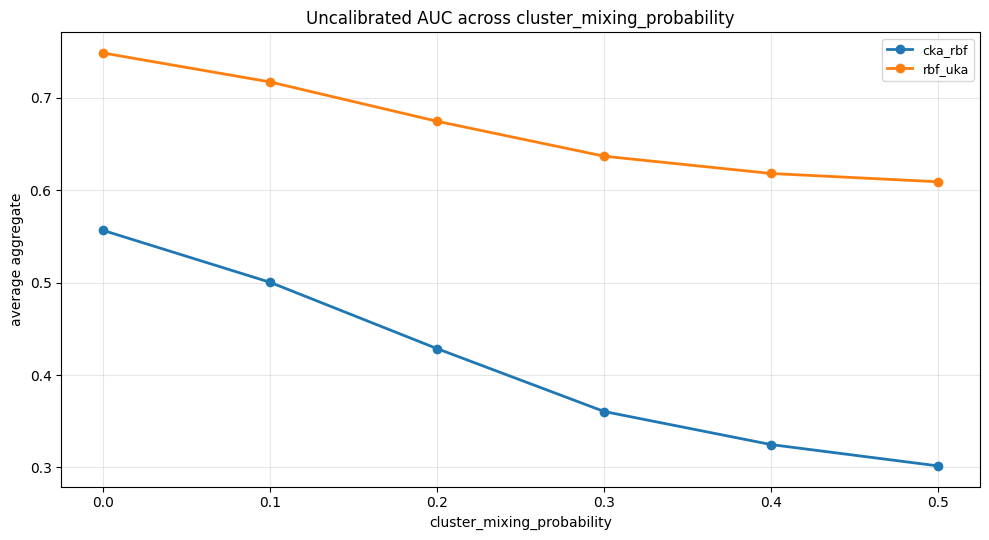

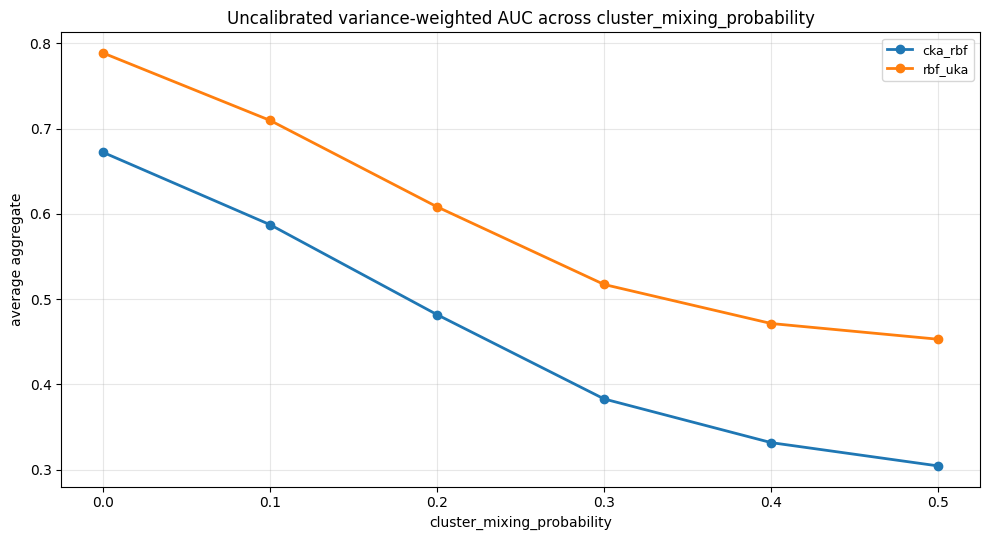

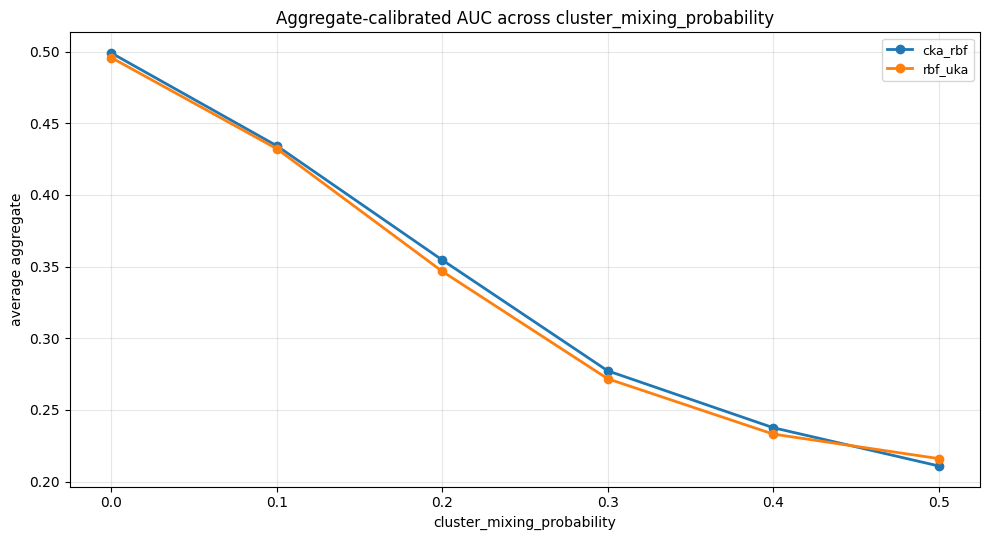

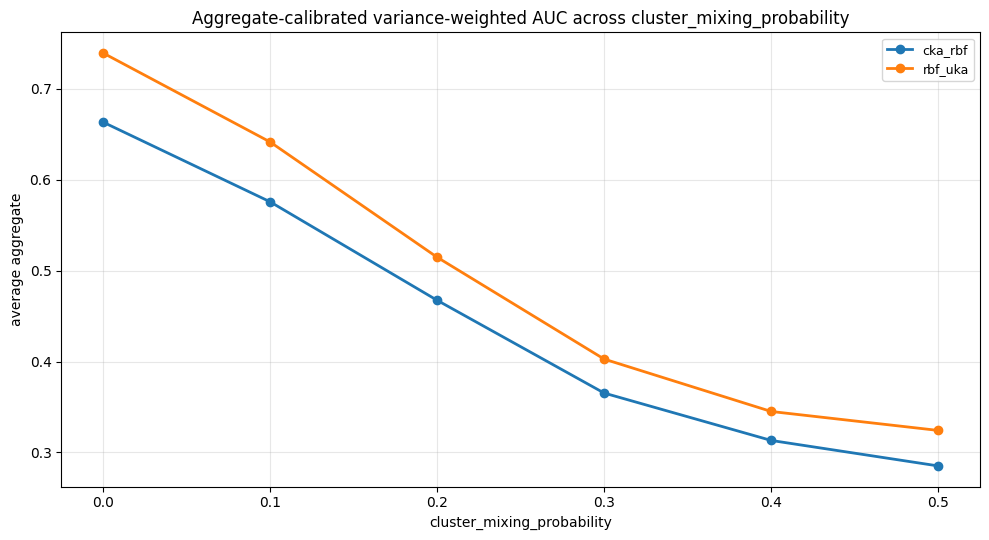

In [ ]:
integration_method = sim_params.get("auc_integration_method", "trapezoidal")
aggregate_kinds = set(sim_params.get("aggregate_calibration_kinds", []))
show_pointwise_calibration = False  # Set to True to include pointwise-calibrated aggregates.
signal_aggregate_results = {}

for metric_name, result in signal_sweep_results.items():
    metric_param_name = result["metric_param_name"]
    metric_sweep_values = result["metric_sweep_values"]
    score_grid = result["score_grid"]
    row_data_values = result["data_param_values"]
    calibration_result = result["calibration_result"]
    aggregate_calibration_enabled = calibration_result is not None and sim_params.get("aggregate_calibration", False)

    uncalibrated_auc = aggregate_signal_auc(
        metric_sweep_values,
        score_grid,
        integration_method=integration_method,
    )
    uncalibrated_var_auc = aggregate_signal_variance_weighted_auc(
        metric_sweep_values,
        score_grid,
        integration_method=integration_method,
    )
    aggregate_result = {
        "uncalibrated_auc": uncalibrated_auc,
        "uncalibrated_var_auc": uncalibrated_var_auc,
    }

    if calibration_result is not None and show_pointwise_calibration:
        pointwise_calibrated_auc = aggregate_signal_auc(
            metric_sweep_values,
            calibration_result.calibrated_scores,
            integration_method=integration_method,
        )
        pointwise_calibrated_var_auc = aggregate_signal_variance_weighted_auc(
            metric_sweep_values,
            calibration_result.calibrated_scores,
            integration_method=integration_method,
        )
        aggregate_result["pointwise_calibrated_auc"] = pointwise_calibrated_auc
        aggregate_result["pointwise_calibrated_var_auc"] = pointwise_calibrated_var_auc
    if aggregate_calibration_enabled and "auc" in aggregate_kinds:
        aggregate_auc_calibration = compute_aggregate_permutation_calibration(
            metric_sweep_values,
            score_grid,
            calibration_result.null_scores,
            aggregate_kind="auc",
            integration_method=integration_method,
            alpha=sim_params["calibration_alpha"],
        )
        aggregate_result["aggregate_auc_calibration"] = aggregate_auc_calibration
    if aggregate_calibration_enabled and "variance_weighted_auc" in aggregate_kinds:
        aggregate_var_auc_calibration = compute_aggregate_permutation_calibration(
            metric_sweep_values,
            score_grid,
            calibration_result.null_scores,
            aggregate_kind="variance_weighted_auc",
            integration_method=integration_method,
            alpha=sim_params["calibration_alpha"],
        )
        aggregate_result["aggregate_var_auc_calibration"] = aggregate_var_auc_calibration
    signal_aggregate_results[metric_name] = aggregate_result

aggregate_plot_specs = [
    ("uncalibrated_auc", "Uncalibrated AUC"),
    ("uncalibrated_var_auc", "Uncalibrated variance-weighted AUC"),
    ("pointwise_calibrated_auc", "Pointwise-calibrated AUC"),
    ("pointwise_calibrated_var_auc", "Pointwise-calibrated variance-weighted AUC"),
    ("aggregate_auc_calibration", "Aggregate-calibrated AUC"),
    ("aggregate_var_auc_calibration", "Aggregate-calibrated variance-weighted AUC"),
]

for result_key, plot_title in aggregate_plot_specs:
    available_metrics = [
        metric_name
        for metric_name, result in signal_aggregate_results.items()
        if result_key in result
    ]
    if not available_metrics:
        continue

    fig, ax = plt.subplots(figsize=(10, 5.5))
    for metric_name in available_metrics:
        aggregate_value = signal_aggregate_results[metric_name][result_key]
        plot_values = (
            aggregate_value.calibrated_scores
            if hasattr(aggregate_value, "calibrated_scores")
            else aggregate_value
        )
        ax.plot(
            signal_sweep_results[metric_name]["data_param_values"],
            plot_values,
            marker="o",
            linewidth=2,
            label=metric_name,
        )

    ax.set_xlabel(data_param_name)
    ax.set_ylabel(f"{integration_method} aggregate")
    ax.set_title(f"{plot_title} across {data_param_name}")
    ax.grid(True, alpha=0.3)
    ax.legend(loc="best", fontsize=9)
    fig.tight_layout()
    fig.savefig(
        os.path.join(figures_path, f"{data_param_name}_all_metrics_{result_key}.png"),
        dpi=300,
    )
    plt.show()
    plt.close(fig)
